# MultiSigBERT

This notebook accompanies the anonymous submission:

**MultiSigBERT: Beyond Survival Analysis through Multimodal and Sequential Modeling in Oncology**  
(ECML-PKDD 2026, double-blind review)

It provides an end-to-end demonstration of the pipeline: data preprocessing, multimodal sequential feature construction, survival modeling, and evaluation.

---

## Clinical Data Confidentiality Notice

Due to clinical confidentiality constraints and applicable data protection regulations (e.g., GDPR), we cannot share real patient-level clinical data used in the study.

To support reproducibility, this notebook is designed to run with:
- a **synthetic dataset** generated with the same schema and statistical structure as the real cohort, or
- a **user-provided dataset** following the format described in `data/README.md`.

No identifying information is included in this repository.


Landmark-Based Survival MultiModelling
---


| Patient | date $t$ | Sentence embedding $v \in \mathbb{R}^q$ | $D \in \{0,1\}$ | $T \ge 0$ |
|:--------|:-----------:|:------------------------------------------:|:-----------------:|:------------:|
| $i$ |$\begin{aligned} &t_1 \\ &\vdots \\ &t_N \end{aligned}$| $\begin{aligned} &v^i_{t_1} \\ &\vdots \\ &v^i_{t_N} \end{aligned}$ | $\delta_i$ | $T_i$ |


Let each patient $i$ be described by a sequence of sentence embeddings $v_t^i \in \mathbb{R}^p$ observed at times $t$, an event indicator $\delta_i \in \{0,1\}$, and a survival time $T_i \ge 0$.
We aim to estimate short-term survival probabilities at a fixed **landmark time** $L$ using information available up to $L$.

### Formal Table - Landmark-Specific Cohort at $L$ Months

| Patient $i$ | Report time $t$ | Embedding $v_t^i \in \mathbb{R}^p$ | Event indicator $\delta_i(L)$ | Total survival time $T_i \ge 0$ | Residual time $R_i = T_i - L$ | Days since start $(t - t_{\text{start},i})$ | Short-history flag $\gamma_i(L)$ | **Landmark $L$** |
|:--------------:|:-----------------:|:-------------------------------------:|:--------------------------------:|:--------------------------------:|:--------------------------------:|:--------------------------------------------:|:----------------------------------:|:------------------:|
| $\mathrm{ID}_i$ | $t_1 \in [L-w,L]$ | $v_{t_1}^i$ | $\delta_i(L)$ | $T_i$ | $T_i - L$ | $(t_1 - t_{\text{start},i})$ | $\gamma_i(L)$ | $L$ |
| $\mathrm{ID}_i$ | $t_2 \in [L-w,L]$ | $v_{t_2}^i$ | $\delta_i(L)$ | $T_i$ | $T_i - L$ | $(t_2 - t_{\text{start},i})$ | $\gamma_i(L)$ | $L$ |
| $\mathrm{ID}_i$ | $\vdots$ | $\vdots$ | $\vdots$ | $\vdots$ | $\vdots$ | $\vdots$ | $\vdots$ | $L$ |
| $\mathrm{ID}_i$ | $t_N \in [L-w,L]$ | $v_{t_N}^i$ | $\delta_i(L)$ | $T_i$ | $T_i - L$ | $(t_N - t_{\text{start},i})$ | $\gamma_i(L)$ | $L$ |

---

**Interpretation**

- $L$: applied landmark time (same for all rows in this cohort).  
- Reports restricted to $t \in [L-w,\,L]$.  
- Patients included only if $T_i \ge L$ (alive at the landmark).  
- $R_i = T_i - L$: residual survival time beyond the landmark.  
- $\gamma_i(L)$: 1 if less than $w$ months of history before $L$.  
- This table represents the DataFrame `df_L` returned by  
  ```python
  define_landmark_cohort(df_OG2,
                         landmark_months=L,
                         window_months=w)

In [1]:
import types
import sys
from numbers import Real, Integral

# Create a fake module to emulate 'sklearn.utils._param_validation'
# (used by skglm in newer versions of scikit-learn, >=1.3)
param_validation = types.ModuleType("sklearn.utils._param_validation")

# Define a minimal replacement for Interval used in _parameter_constraints
class Interval:
    def __init__(self, dtype, left, right, closed="neither"):
        self.dtype = dtype
        self.left = left
        self.right = right
        self.closed = closed

# Define a minimal replacement for StrOptions used in _parameter_constraints
class StrOptions:
    def __init__(self, options):
        self.options = set(options)

# Add the custom classes to the fake module
param_validation.Interval = Interval
param_validation.StrOptions = StrOptions

# Inject the fake module into sys.modules before skglm is imported
# This prevents skglm from raising an ImportError if sklearn < 1.3
sys.modules["sklearn.utils._param_validation"] = param_validation

In [2]:
import pandas as pd
import torch
import numpy as np
import time
import warnings
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import os

# Add the src directory to the Python path
notebook_dir = os.path.dirname(os.path.abspath("__file__"))
src_path = os.path.abspath(os.path.join(notebook_dir, '..', 'src/multisigbert'))
if src_path not in sys.path:
    sys.path.insert(0, src_path)

# Now import our custom modules
from _utils import *
from descriptive_stats_pkg import *
from compression_pkg import *
from survival_analysis_pkg import *
from metrics_plot_results_pkg import *

/Applications/anaconda3/envs/multisigbert-env/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
start_notebook = time.time()

# I) Data Importation

In [5]:
df_OG = global_data_import(path_import = "../data/data_real.csv", nrows=None)


----- Total import time: 103.51 seconds (1.73 minutes)
Number of unique patients: 7121


In [6]:
df_OG = convert_date_columns(df_OG)

In [7]:
df_OG2, df_surv = compute_survival_time(df_OG, verbose=False)

In [8]:
results_summary = []

# MultiModal LandMark

## Import Strutured Data 

In [9]:
path_seq = './donnees-evolutives.csv' # Table of sequential structured data
ippr_conforme = pd.read_csv('./patients_conformes.csv') # ID of studied patients 


In [10]:
df_seq, mapping_type_libelle = load_sequence_data(
    path_seq,
    ippr_conforme,
    id_col_original = "IPPR",
    id_col_final = "ID")

In [11]:
covariables_list = ['PO', 'KAR', 'PS', 'IMC', 'TA', 'PL', 'TAI']
ordinal_codes=["PS", "KAR"]

In [12]:
df_wide, mapping_libelle_filtered = build_wide_table_and_metadata(
    df_seq=df_seq,
    mapping_type_libelle=mapping_type_libelle,
    ordinal_codes=ordinal_codes,
    covariables_list=covariables_list)

## Process sur `df_meta`

In [13]:
# Import the survival metadata
df_meta = pd.read_csv('./survival_metadata_by_patient.csv')
df_meta = df_meta.rename(columns={'IPPR': 'ID'})

In [14]:
# Merge the metadata into the main study dataframe using a left join on 'IPPR'
df_wide_meta = df_wide.merge(df_meta, on='ID', how='left')

# Display the first 3 rows of the merged dataframe
# df_wide_meta.head(3)

# Rename 'DATE_DONNEE' into 'date_creation'
df_wide_meta = df_wide_meta.rename(columns={'DATE_DONNEE': 'date_creation'})

df_wide_meta = convert_date_columns(df_wide_meta)

In [15]:
df_merge = df_OG2.merge(df_wide_meta[['ID'] + covariables_list], on='ID', how='left')

In [16]:
df_merge_clean = deduplicate_by_timestamp(
    df_merge=df_merge,
    covariables_list=covariables_list,
    var_id="ID",
    var_crea="date_creation",
    var_embd="embeddings"
)

Found 18142571 duplicated rows sharing the same (ID, date_creation). Proceeding to deduplicate...
Deduplication done: 18142571 rows affected.


In [17]:
seq_var_patients_list = df_wide_meta['ID'].dropna().unique().tolist()
df_merge_clean = df_merge_clean[df_merge_clean['ID'].isin(seq_var_patients_list)].copy()
df_merge_clean['ID'].nunique()

7074

In [18]:
df_multimodal = df_merge_clean.copy()
df_multimodal = df_multimodal.reset_index(drop=True)

In [19]:
print(f"Avaiblable patient for MultiModal: {df_multimodal['ID'].nunique()}")

Avaiblable patient for MultiModal: 7074


In [20]:
# ----------------------- :: Reports Only – Landmark Analysis :: -----------------------
k_comp = 25; max_reports = 221
L_chosen = 36; w_chosen = 12

print(f" ---------- :: Reports Only :: ----------\n ---------- L_chosen = {L_chosen}; w_chosen = {w_chosen} ---------- ")

# Build the landmark cohort
df_L, patients_L, df_gamma_L = define_landmark_cohort(
    df_multimodal,
    landmark_months=L_chosen,
    window_months=w_chosen
)

# Count number of clinical reports in the window
df_counts = (
    df_L.groupby("ID")
        .size()
        .reset_index(name="n_reports")
)
mean_reports = df_counts["n_reports"].mean()
std_reports = df_counts["n_reports"].std(ddof=1)

 ---------- :: Reports Only :: ----------
 ---------- L_chosen = 36; w_chosen = 12 ---------- 
[Landmark 36 mo] Patients kept: 3674/7074 (3400 excluded)
  → Short-history γ=1: 2473/3674 = 67.3%
  → Observations kept: 19448/146132 (13.3% retained, 86.7% removed)
  → Residual survival R_i computed (min=0.0 days).
  → Landmark events computed: DEATH_L sum = 15453.


In [21]:
df_L['ID'].nunique()

2527

In [22]:
mapping_path = "./mapping_ID_L36_w12.csv"
df_mapping = pd.read_csv(mapping_path)

# Assure que les deux colonnes sont en string
df_L["ID"] = df_L["ID"].astype(str)
df_mapping["ID_original"] = df_mapping["ID_original"].astype(str)

# Merge propre
df_L = df_L.merge(
    df_mapping[["ID_original", "cluster_spectral"]],
    left_on="ID",
    right_on="ID_original",
    how="left"
).drop(columns=["ID_original"])

In [24]:
# Check NaN count
print("NaN in cluster_spectral:", df_L["cluster_spectral"].isna().sum())

NaN in cluster_spectral: 0


In [25]:
# Define output path
# output_path = "../data/df_study_real_L36_w12.csv"

# Export dataframe
# df_all.to_csv(output_path, index=False)

In [26]:
# df_gamma_L.to_csv("../data/df_gamma_L36.csv", index=False)

## Only Reports

In [27]:
# Ensure consistent types for merge
df_gamma_L["ID"] = df_gamma_L["ID"].astype(str)
df_mapping["ID_original"] = df_mapping["ID_original"].astype(str)

# Create df_static_covar by joining spectral_cluster via original ID
df_static_covar = df_gamma_L.merge(
    df_mapping[["ID_original", "cluster_spectral"]],
    left_on="ID",
    right_on="ID_original",
    how="left"
).drop(columns=["ID_original"])

In [28]:
# Train-test construction
df_train_new_OG, test_groups = make_train_test(df_L)

# PCA compression
_, R_comp = pca_compression(df_train_new_OG, k_comp, verbose=True)

df_all = df_L.copy()

Compression dimension (bar_p): 25
Explained variance ratio: 97.0109%



Processing cluster 0

### Processing for max_reports = 221 ###

Total number of individuals in the train set: 361
Total number of individuals in the validation set: 361

Timestamps normalized for each patient to the [0, 1] range.
Path dimension: 26
Signature components (order 2): 702
Percentage of rows with NaNs in signature columns: 0.00%
Number of events (deaths): 134 out of 361 (37.12%)
Static covariates added: 1 (total features: 703, signature features: 702)
Number of individuals in design matrix: 361
Signature feature computation took 0.95s

 --------------- Linear LASSO training --------------- 
 --------> X.shape: (361, 703)

 --------> y.shape: (361, 2)



/Applications/anaconda3/envs/multisigbert-env/lib/python3.8/site-packages/skglm/solvers/prox_newton.py:433: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 1, 'A', False, aligned=True), Array(float64, 1, 'C', False, aligned=True))
  grad[idx] = X[:, j] @ raw_grad


Number of nonzero coefficients in solution: 47 out of 703.
w_sk.shape: (703,)
---
NaNs in risk_score: 0
Infs in risk_score: 0
C-index on training data: 0.770
Execution time: 13.42 seconds (0.22 minutes)

        Scores:
        C-index        = 0.770
        Log-likelihood = -1.61
        
 ---------------  --------------- 
Timestamps normalized for each patient to the [0, 1] range.
Path dimension: 26
Signature components (order 2): 702
Percentage of rows with NaNs in signature columns: 0.00%
Number of events (deaths): 18 out of 37 (48.65%)

--- Test Case 1 ---
---
NaNs in risk_score: 0
Infs in risk_score: 0
Concordance index on test set: 0.637
--- ---
Timestamps normalized for each patient to the [0, 1] range.
Path dimension: 26
Signature components (order 2): 702
Percentage of rows with NaNs in signature columns: 0.00%
Number of events (deaths): 17 out of 36 (47.22%)

--- Test Case 2 ---
---
NaNs in risk_score: 0
Infs in risk_score: 0
Concordance index on test set: 0.686
--- ---
Time

Computing Brier Scores: 100%|███████████████████| 10/10 [00:00<00:00, 16.31it/s]


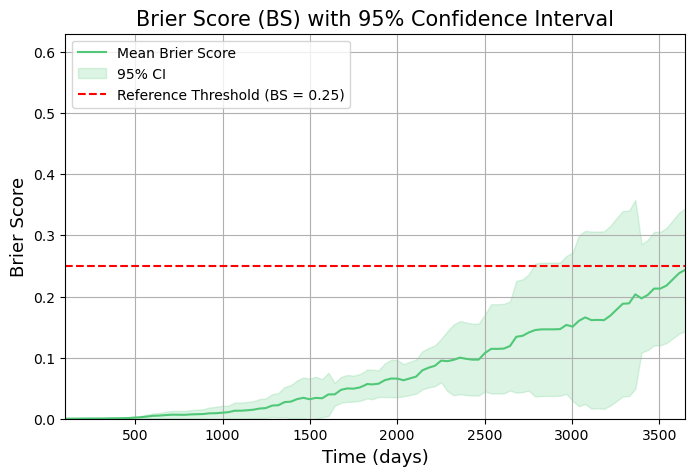


Processing cluster 1

### Processing for max_reports = 221 ###

Total number of individuals in the train set: 862
Total number of individuals in the validation set: 861

Timestamps normalized for each patient to the [0, 1] range.
Path dimension: 26
Signature components (order 2): 702
Percentage of rows with NaNs in signature columns: 0.00%
Number of events (deaths): 633 out of 862 (73.43%)
Static covariates added: 1 (total features: 703, signature features: 702)
Number of individuals in design matrix: 862
Signature feature computation took 2.34s

 --------------- Linear LASSO training --------------- 
 --------> X.shape: (862, 703)

 --------> y.shape: (862, 2)

Number of nonzero coefficients in solution: 47 out of 703.
w_sk.shape: (703,)
---
NaNs in risk_score: 0
Infs in risk_score: 0
C-index on training data: 0.728
Execution time: 1.27 seconds (0.02 minutes)

        Scores:
        C-index        = 0.728
        Log-likelihood = -4.14
        
 ---------------  --------------- 
Tim

Computing Brier Scores: 100%|███████████████████| 10/10 [00:01<00:00,  8.56it/s]


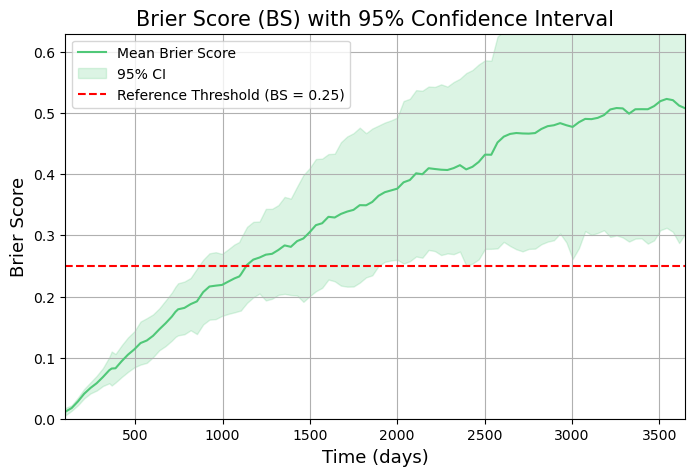


Processing cluster 2

### Processing for max_reports = 221 ###

Total number of individuals in the train set: 40
Total number of individuals in the validation set: 41

Timestamps normalized for each patient to the [0, 1] range.
Path dimension: 26
Signature components (order 2): 702
Percentage of rows with NaNs in signature columns: 0.00%
Number of events (deaths): 28 out of 40 (70.00%)
Static covariates added: 1 (total features: 703, signature features: 702)
Number of individuals in design matrix: 40
Signature feature computation took 0.11s

 --------------- Linear LASSO training --------------- 
 --------> X.shape: (40, 703)

 --------> y.shape: (40, 2)

Number of nonzero coefficients in solution: 34 out of 703.
w_sk.shape: (703,)
---
NaNs in risk_score: 0
Infs in risk_score: 0
C-index on training data: 0.880
Execution time: 2.07 seconds (0.03 minutes)

        Scores:
        C-index        = 0.880
        Log-likelihood = -1.31
        
 ---------------  --------------- 
Timestamps

Computing Brier Scores: 100%|███████████████████| 10/10 [00:00<00:00, 56.63it/s]


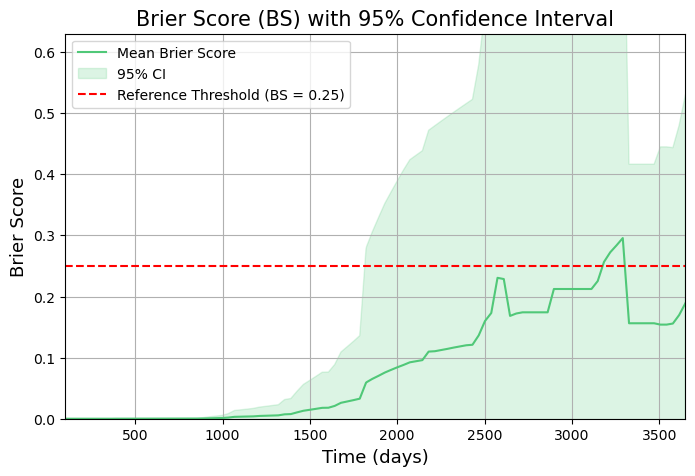

In [29]:
# ============================================================
# CLUSTER-SPECIFIC LEARNING PIPELINE
# One Cox / SigBERT model per spectral cluster
# Adds: train size, test size (unique patients), deaths/censored summary
# ============================================================

import time

results_summary_clusters = []
cluster_models = {}
cluster_outputs = {}

clusters = sorted(df_L["cluster_spectral"].dropna().unique())

start_global = time.time()

for cl in clusters:

    print("\n==============================")
    print(f"Processing cluster {cl}")
    print("==============================")

    start_cluster = time.time()

    # --------------------------------------------------------
    # 1) Restrict to cluster (keep all observations per patient)
    # --------------------------------------------------------
    df_cluster = df_L[df_L["cluster_spectral"] == cl].copy()

    n_patients_cluster = df_cluster["ID"].nunique()
    if n_patients_cluster < 10:
        print(f"Cluster {cl} skipped (too few patients: {n_patients_cluster}).")
        continue

    # Deaths / censored at patient-level (avoid multi-observation leakage)
    df_patient_outcome = (
        df_cluster
        .sort_values("date_creation")
        .groupby("ID", as_index=False)
        .agg(DEATH_L=("DEATH_L", "max"))
    )
    n_deaths = int(df_patient_outcome["DEATH_L"].sum())
    n_censored = int(len(df_patient_outcome) - n_deaths)
    death_censor_str = f"{n_deaths}/{n_censored}"

    # --------------------------------------------------------
    # 2) Train-test split INSIDE cluster (patient-level split)
    # --------------------------------------------------------
    df_train_new_OG, test_groups = make_train_test(df_cluster)

    # Unique patients in train/test
    n_patients_train = df_train_new_OG["ID"].nunique()
    n_patients_test_total = pd.concat(
        [tg[["ID"]] for tg in test_groups],
        axis=0,
        ignore_index=True
    )["ID"].nunique()

    # --------------------------------------------------------
    # 3) PCA compression learned on cluster-train only
    # --------------------------------------------------------
    _, R_comp = pca_compression(df_train_new_OG, k_comp, verbose=False)

    df_all_cluster = df_cluster.copy()

    # --------------------------------------------------------
    # 4) Run SigBERT process (cluster-specific model)
    # --------------------------------------------------------
    lambda_l1_CV = 0.35

    (
        df_results,
        cph,
        df_survival_train,
        w_sk,
        scores,
        X_train,
        y_train_raw,
        y_train_backend,
        c_index_train,
        c_index_test_list,
        c_index_test_mean,
        c_index_test_std,
        df_survival_test_list,
        df_study_all_cluster
    ) = global_sigbert_process(
        max_reports         = max_reports,
        df_all              = df_all_cluster,
        df_train_new_OG     = df_train_new_OG,
        test_groups         = test_groups,
        R_comp              = R_comp,
        lambda_l1_CV        = lambda_l1_CV,
        print_progress      = False,
        order_sign          = 2,
        var_duration        = "R",
        var_death           = "DEATH_L",
        var_struct_seq_list = None,
        df_matrix_covar     = df_gamma_L[df_gamma_L["ID"].isin(df_cluster["ID"])],
        use_other_covar     = True,
        use_standard_scale  = False,
    )

    # --------------------------------------------------------
    # 5) Post-processing
    # --------------------------------------------------------
    non_nuls_coefs = int((w_sk != 0).sum())

    lower_bound, upper_bound = jackknife_confidence_interval(
        c_index_test_list
    )

    evaluation_times = np.sort(np.unique(np.concatenate((
        np.linspace(100, 3650, 100),
        [365, 730, 1095, 1825, 3650]
    ))))

    brier_scores_array, bs_mean, bs_std, bs_upper, bs_lower = \
        evaluate_brier_score_multiple_tests(
            df_survival_test_list = df_survival_test_list,
            cph                  = cph,
            evaluation_times     = evaluation_times,
            brier_score_function = brier_score_ipcw_with_cph,
            export_fig           = False,
            verbose              = False
        )

    idx_3y = np.where(evaluation_times == 1095)[0][0]
    ibs_3y_per_test = brier_scores_array[:, idx_3y]

    IBS_3y_mean = np.mean(ibs_3y_per_test)
    IBS_3y_std  = np.std(ibs_3y_per_test, ddof=1)

    lower_IBS_3y, upper_IBS_3y = jackknife_confidence_interval(
        ibs_3y_per_test
    )

    duration_cluster = (time.time() - start_cluster) / 60

    # --------------------------------------------------------
    # 6) Store model & outputs
    # --------------------------------------------------------
    cluster_models[cl] = cph

    cluster_outputs[cl] = {
        "n_patients_cluster": n_patients_cluster,
        "n_patients_train": n_patients_train,
        "n_patients_test_total": n_patients_test_total,
        "death_censor": death_censor_str,
        "c_index_train": c_index_train,
        "c_index_test_mean": c_index_test_mean,
        "c_index_test_std": c_index_test_std,
        "IBS_3y_mean": IBS_3y_mean,
        "IBS_3y_std": IBS_3y_std
    }

    results_summary_clusters.append({
        "Cluster": cl,
        "Patients (cluster)": n_patients_cluster,
        "Patients (train)": n_patients_train,
        "Patients (test total)": n_patients_test_total,
        "Deaths/Censored": death_censor_str,
        "lambda_LASSO": lambda_l1_CV,
        "non_nuls_coefs": non_nuls_coefs,
        "total_coefs": len(w_sk),
        "C-index Train": f"{c_index_train:.3f}",
        "Mean C-index (Test)": f"{c_index_test_mean:.3f} (sd {c_index_test_std:.3f})",
        "Jackknife CI 95%": f"[{lower_bound:.3f}, {upper_bound:.3f}]",
        "IBS@3y": f"{IBS_3y_mean:.4f} (sd {IBS_3y_std:.4f})",
        "IBS@3y CI95%": f"[{lower_IBS_3y:.4f}, {upper_IBS_3y:.4f}]",
        "Execution Time (min)": np.round(duration_cluster, 2)
    })

In [30]:
# ============================================================
# Final summary dataframe
# ============================================================

df_cluster_summary = pd.DataFrame(results_summary_clusters)

total_runtime = (time.time() - start_global) / 60
print(f"\nTotal cluster-wise training time: {total_runtime:.2f} minutes")


Total cluster-wise training time: 0.54 minutes


In [31]:
df_cluster_summary

,Cluster,Patients (cluster),Patients (train),Patients (test total),Deaths/Censored,lambda_LASSO,non_nuls_coefs,total_coefs,C-index Train,Mean C-index (Test),Jackknife CI 95%,IBS@3y,IBS@3y CI95%,Execution Time (min)
0,0,722,361,361,293/429,0.35,47,703,0.770,0.700 (sd 0.060),"[0.662, 0.737]",0.0131 (sd 0.0071),"[0.0088, 0.0175]",0.30
1,1,1724,862,862,1281/443,0.35,47,703,0.728,0.704 (sd 0.049),"[0.674, 0.735]",0.2327 (sd 0.0303),"[0.2139, 0.2515]",0.19
2,2,81,40,41,55/26,0.35,34,703,0.880,0.567 (sd 0.344),"[0.353, 0.780]",0.0033 (sd 0.0059),"[-0.0004, 0.0069]",0.05


In [32]:
duration_notebook = time.time() - start_notebook
print(f" NoteBook total duration: {duration_notebook:.2f}s i.e. {duration_notebook / 60:.2f}min.")

 NoteBook total duration: 284.46s i.e. 4.74min.
